# Exploratory Data Analysis

## Table of Contents

1. [Loading Data & Overview](#1.-Loading-Data-&-Overview)
2. [Categorical Variables](#2.-Categorical-Variables-)
3. [Numeric Variables](#3.-Numeric-Variables)
4. [Correlation Analysis](#4.-Correlation-Analysis)
5. [Genre Analysis](#5.-Genre-Analysis)
6. [Conclusion](#6.-Conclusion)

## 1. Loading Data & Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('tracks2026.csv')

In [2]:
df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


In [3]:
df.tail()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop
1999,46qnV2b4tq0QqJwIoZwMyJ,25.0,244026,False,0.746,0.570,7,-10.599,1,0.0389,0.6660,0.000005,0.3200,0.657,109.929,4,synth-pop


Each row is a track. There are 17 different columns. Three columns (track_id, explicit and track_genre) contain something else than numbers, rest contain numbers. Track id is the id of the track, so it can be used to identify the track.

## 2. Categorical Variables

In [4]:
df['explicit'].value_counts(dropna=False)

explicit
False    1777
True      223
Name: count, dtype: int64

In [5]:
df['track_genre'].value_counts(dropna=False)

track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64

Explicit and track_genre -columns can be left as they are as they do not contain any missing values. Explicit-column is unbalanced which needs to be considered later on in the modelling part.

In [6]:
df['mode'].value_counts(dropna=False)

mode
1    1275
0     725
Name: count, dtype: int64

In [7]:
df['key'].value_counts(dropna=False)

key
0     243
1     193
7     192
9     187
5     184
2     173
8     157
11    154
6     152
4     147
10    143
3      75
Name: count, dtype: int64

In [8]:
df['time_signature'].value_counts(dropna=False)

time_signature
4    1838
3     115
1      27
5      20
Name: count, dtype: int64

Column 'mode' seems to be categorical, containing only values 0 or 1. Column 'key' is Pitch class map of integers 0-11 and also categorical. Column 'time_signature' is also categorical and is heavily focused in value of 4 (almost all the data).

## 3. Numeric Variables

In the following, the numeric columns will be examined for distributions, outliers, and missing values.

In [9]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


Columns 'popularity', 'danceability', 'energy', 'loudness' and 'tempo' have missing values. They all seem to be in the same rows.

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print(missing_summary.to_string())
print(f"\nTotal rows with at least one NaN: {df.isnull().any(axis=1).sum()}")

              Missing Count  Missing %
popularity               40       2.00
danceability             40       2.00
energy                   40       2.00
loudness                 39       1.95
tempo                    40       2.00

Total rows with at least one NaN: 40


In [11]:
df_nans = df[df["popularity"].isnull() | df["danceability"].isnull() | df["energy"].isnull() | df["loudness"].isnull() | df["tempo"].isnull() ]
df_nans.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
29,1n5gnI3Wue9WBpYFOIQNh1,NaN,341386,False,NaN,NaN,11,NaN,1,0.3310,0.237,0.000000,0.0791,0.676,NaN,4,pop
56,0hcvwkxhxlIRdeLb1dWJBT,NaN,245187,False,NaN,NaN,5,NaN,0,0.0372,0.102,0.000000,0.2290,0.602,NaN,4,synth-pop
65,1PYCOTJ2g3WJkFsgLlzIEW,NaN,185133,True,NaN,NaN,8,NaN,1,0.0502,0.512,0.000000,0.0638,0.966,NaN,4,r-n-b
99,08HJeHs0U9iSbDWX0sWIem,NaN,169371,False,NaN,NaN,9,NaN,1,0.0999,0.739,0.000000,0.0919,0.316,NaN,4,r-n-b
128,08EzywoYzT4unsQXslM9RA,NaN,268560,False,NaN,NaN,5,NaN,1,0.0262,0.257,0.000013,0.1780,0.870,NaN,4,synth-pop


### Popularity, duration, danceability, energy, loudness, speechiness

Let us look the numerical values in two parts, first columns 'popularity','duration_ms', 'danceability', 'energy', 'loudness', 'speechiness'.

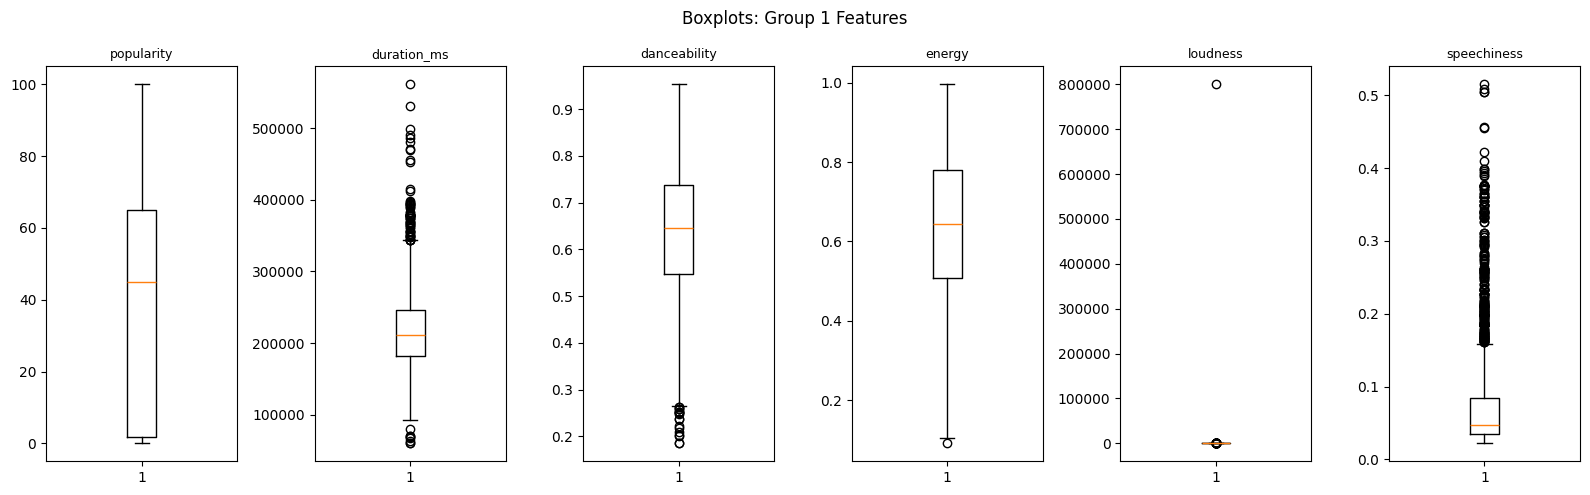

In [12]:
cols_group1 = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness']
fig, axes = plt.subplots(1, len(cols_group1), figsize=(16, 5))
for ax, col in zip(axes, cols_group1):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
fig.suptitle('Boxplots: Group 1 Features', fontsize=12)
plt.tight_layout()
plt.show()

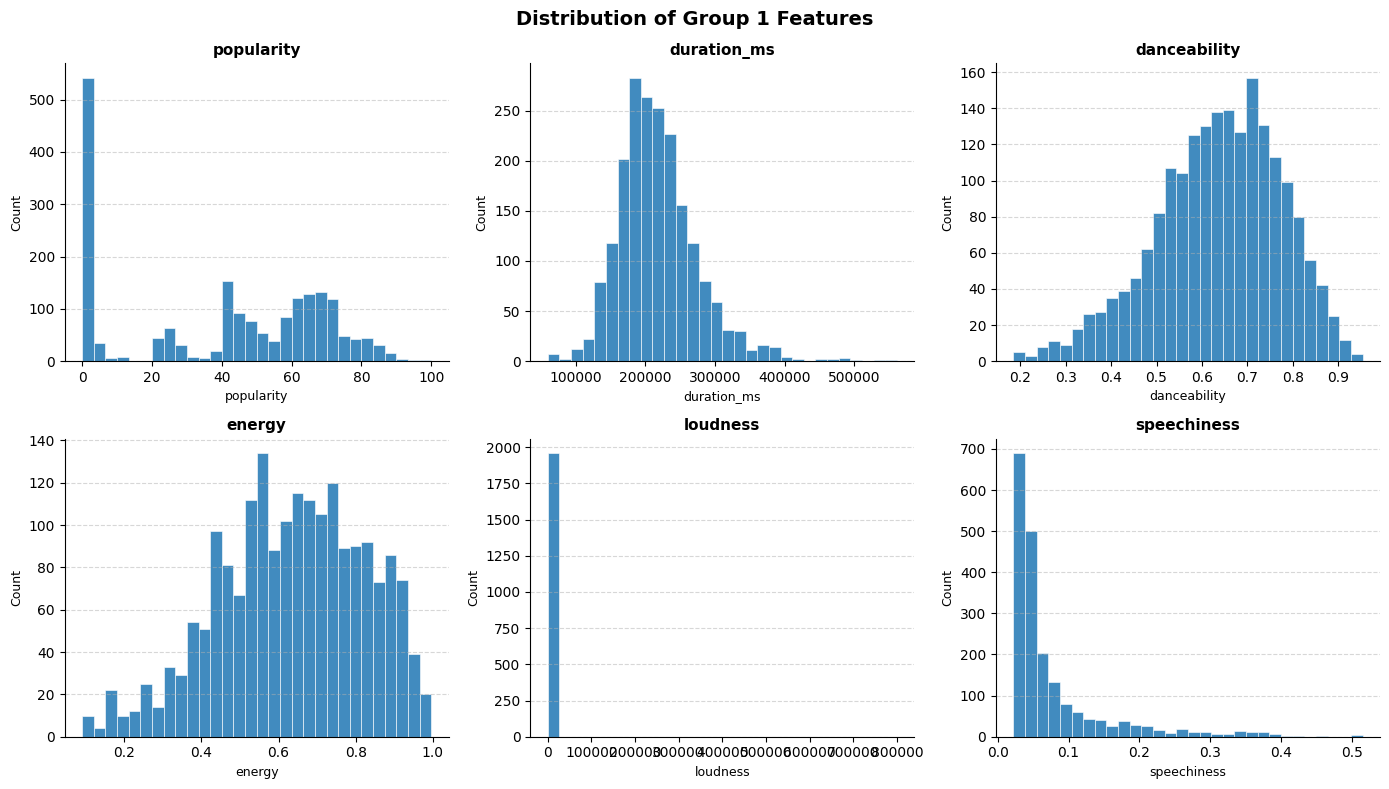

In [13]:
cols_group1_hist = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_group1_hist):
    data = df[col].dropna()
    ax.hist(data, bins=30, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Distribution of Group 1 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

As can be seen in the boxplot, duration, danceability, energy, loudness and speechines all have outliers. Also the scale of duration is far more dominant than other features. All of these columns are at least a bit skewed, which can be seen in the histograms.

In [14]:
df[df['loudness']> 0]

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1289,39ujbBjTwwqUFySaCYDMMT,NaN,178604,False,NaN,NaN,1,800000.0,0,0.0851,0.485,0.0,0.318,0.49,NaN,4,pop


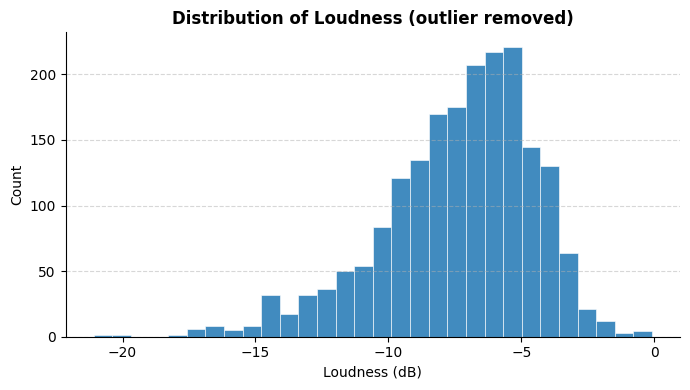

In [15]:
loudness = df[df['loudness'] <= 0]['loudness'].to_numpy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(loudness, bins=30, edgecolor='white', linewidth=0.5, alpha=0.85)
ax.set_title('Distribution of Loudness (outlier removed)', fontsize=12, fontweight='bold')
ax.set_xlabel('Loudness (dB)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

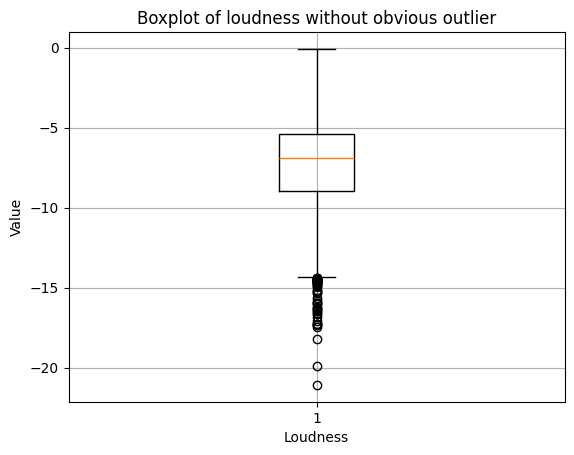

In [16]:
plt.boxplot(loudness)
plt.title('Boxplot of loudness without obvious outlier')
plt.xlabel('Loudness')
plt.ylabel('Value')
plt.grid()
plt.show()

There seems to be one incorrect datapoint in the loudness column (record 1289), as other values are negative and the value of the record in question is 800000.

Suggestion for data preparation of the columns 'popularity','duration_ms', 'danceability', 'energy', 'loudness', 'speechiness':
Drop the record of 1289.
For column popularity, use standard scaler and log transformation.
For columns rest columns, use robust scaler and log transformation.

### Acousticness, instrumentalness, liveness, valence, tempo

Let us next explore columns 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'.

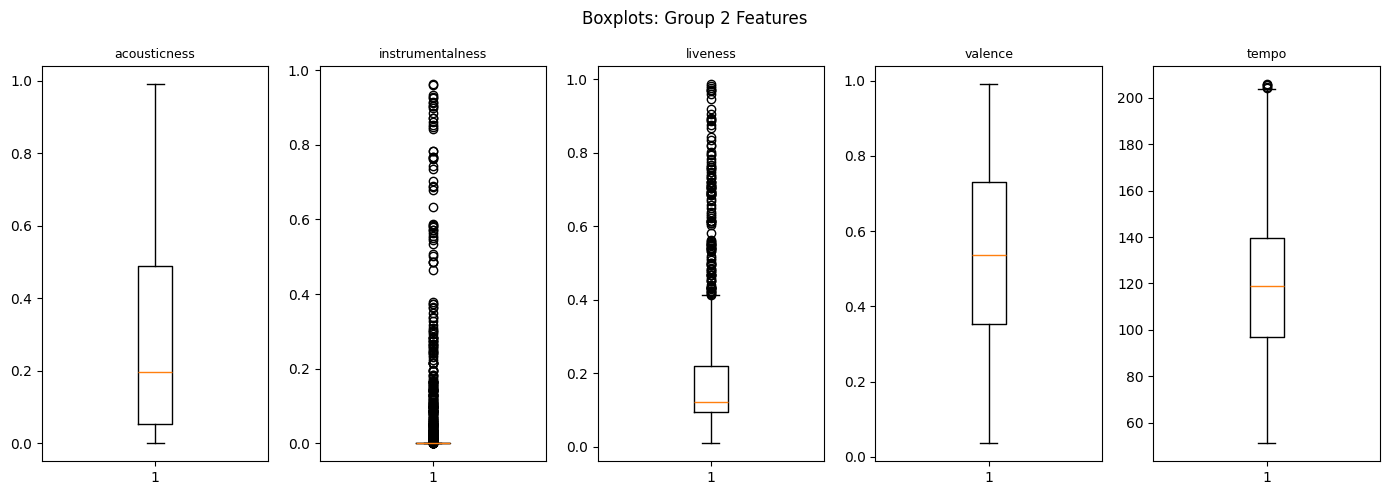

In [17]:
cols_group2 = ['acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
fig, axes = plt.subplots(1, len(cols_group2), figsize=(14, 5))
for ax, col in zip(axes, cols_group2):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
fig.suptitle('Boxplots: Group 2 Features', fontsize=12)
plt.tight_layout()
plt.show()

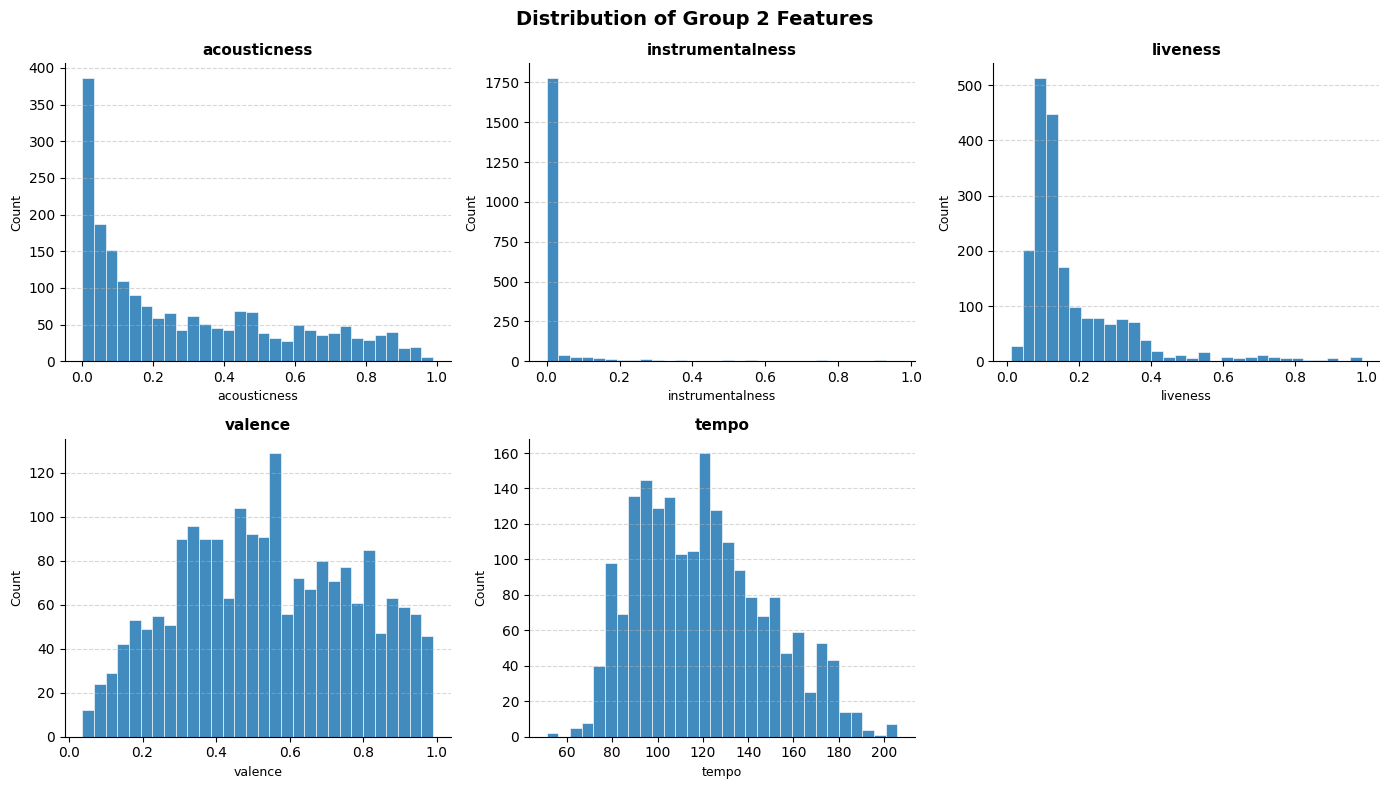

In [18]:
cols_group2_hist = ['acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_group2_hist):
    data = df[col].dropna()
    ax.hist(data, bins=30, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_visible(False)

fig.suptitle('Distribution of Group 2 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

As can be seen, instrumentalness, liveness and tempo have outliers. All of these columns are at least a bit skewed but acousticness, instrumentalness and liveness the most.

Suggestion for data preparation:
For acousticness and valence, use standard scaler and log transformation.
For rest of the columns, use robust scaler and log transformation.

## 4. Correlation Analysis

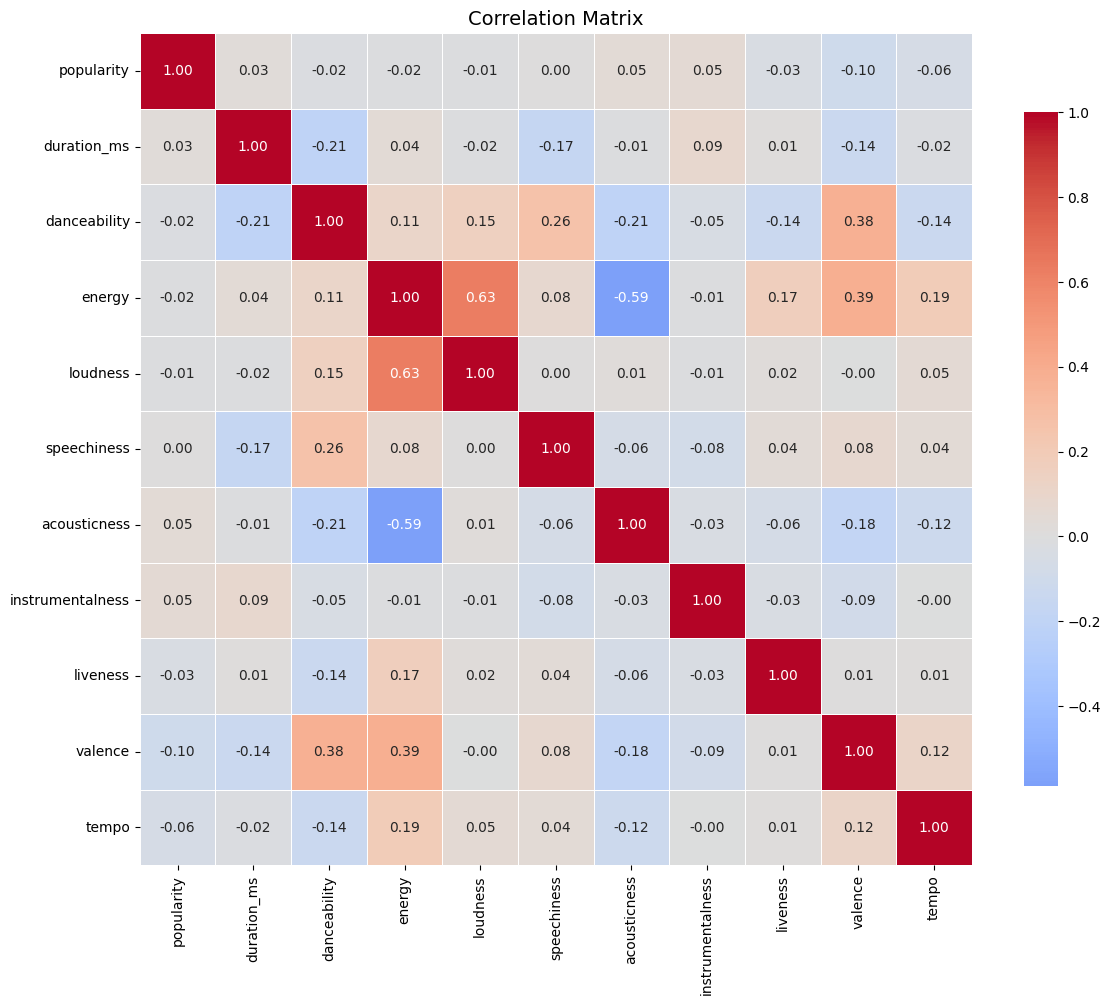

In [19]:
numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

As can be seen, the highest correlation between the variables is between loudnes and energy (0.632503). This is somewhat understandable as the more loud the music is, the more it physically feels, and that may lead to being more energized.

Lowest correlation is between acoustiness and energy (-0.588686). This is also somewhat explainable, as acoustic songs tend to be a bit slower and thus not so energized songs.

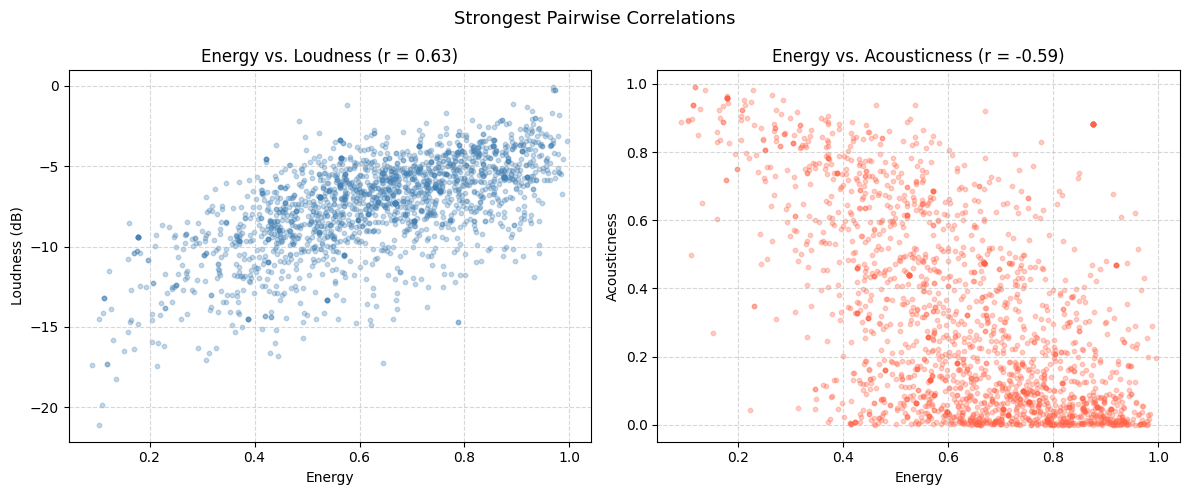

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_clean = df[df['loudness'] <= 0].dropna(subset=['energy', 'loudness', 'acousticness'])

axes[0].scatter(df_clean['energy'], df_clean['loudness'], alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Loudness (dB)')
axes[0].set_title('Energy vs. Loudness (r = 0.63)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(df_clean['energy'], df_clean['acousticness'], alpha=0.3, s=10, color='tomato')
axes[1].set_xlabel('Energy')
axes[1].set_ylabel('Acousticness')
axes[1].set_title('Energy vs. Acousticness (r = -0.59)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Strongest Pairwise Correlations', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Genre Analysis
The following section examines differences between genres in terms of popularity and audio features.

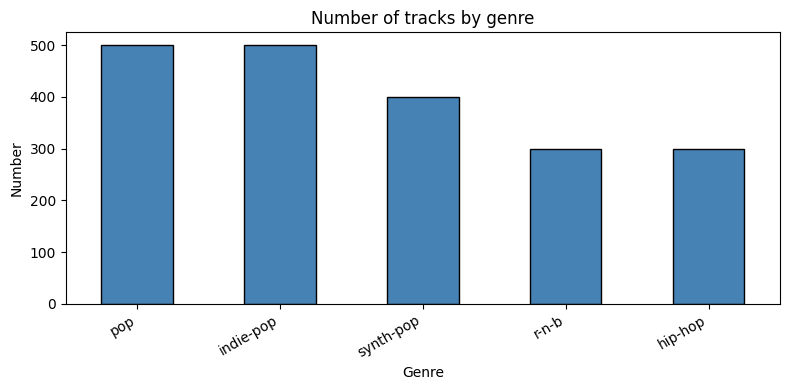

In [21]:
plt.figure(figsize=(8, 4))
df['track_genre'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of tracks by genre')
plt.xlabel('Genre')
plt.ylabel('Number')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

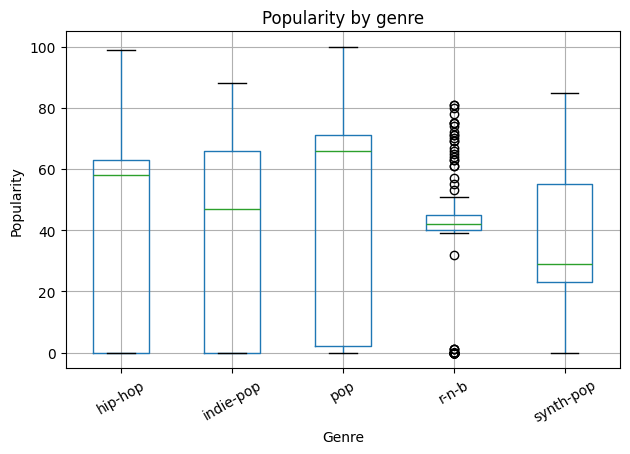

In [22]:
plt.figure(figsize=(10, 5))
df.boxplot(column='popularity', by='track_genre', rot=30)
plt.title('Popularity by genre')
plt.suptitle('')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

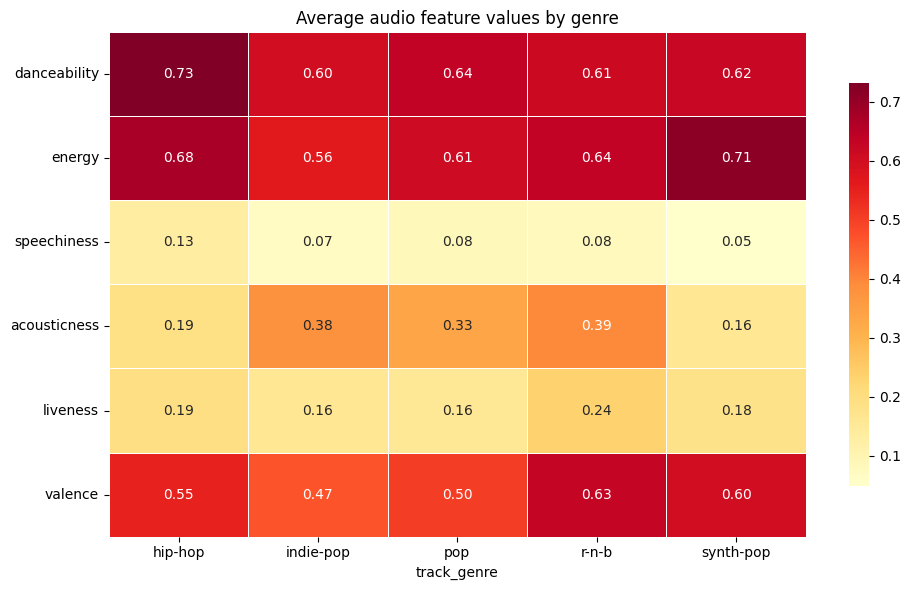

In [23]:
feature_cols = ['danceability', 'energy', 'speechiness',
                'acousticness', 'liveness', 'valence']

genre_means = df.groupby('track_genre')[feature_cols].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(genre_means.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Average audio feature values by genre')
plt.tight_layout()
plt.show()

/tmp/ipykernel_71110/2346959575.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_valid, x='track_genre', y=feat, ax=ax,
/tmp/ipykernel_71110/2346959575.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_71110/2346959575.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_valid, x='track_genre', y=feat, ax=ax,
/tmp/ipykernel_71110/2346959575.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.ge

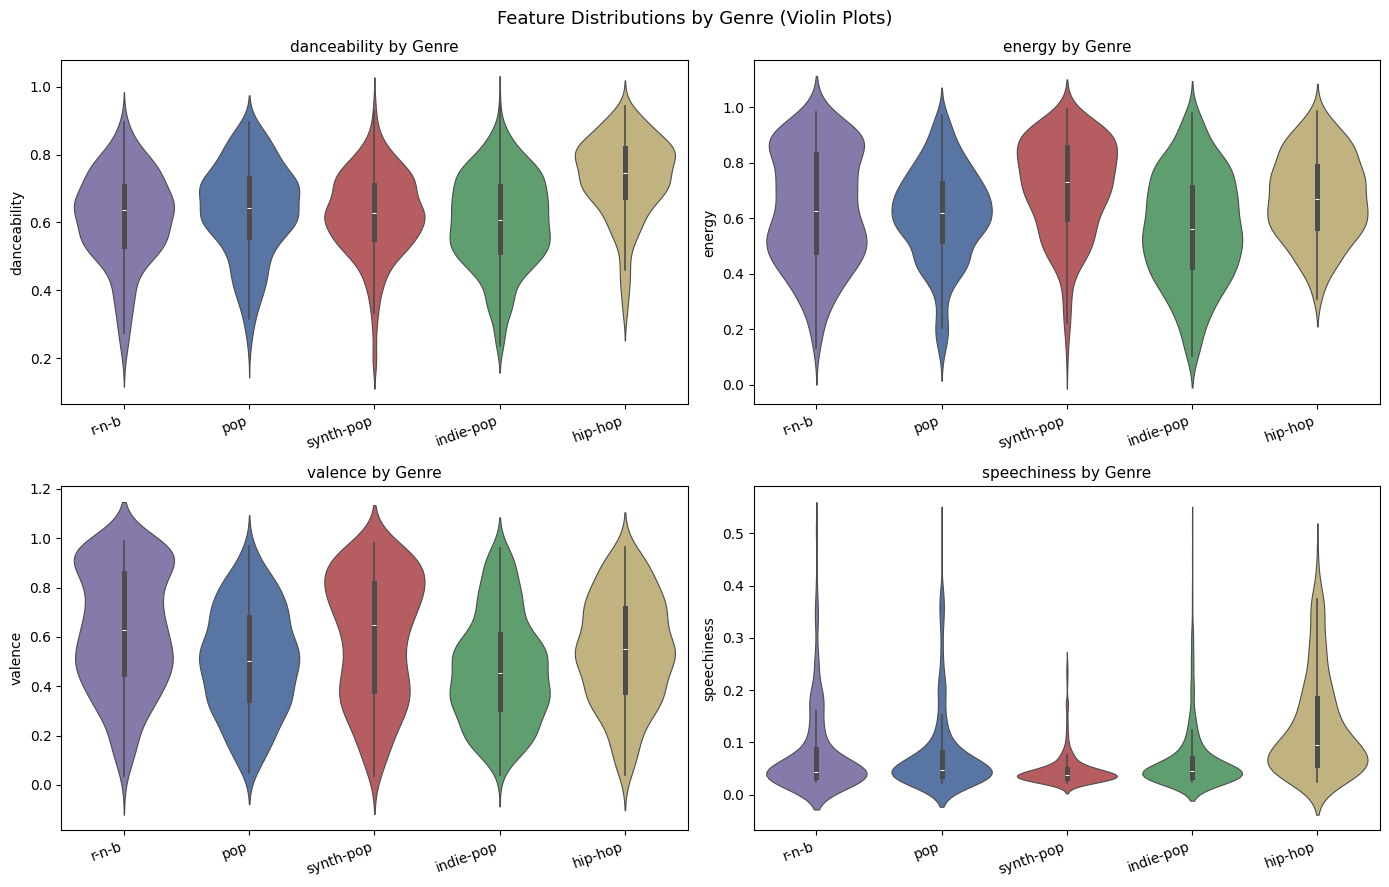

In [24]:
key_features = ['danceability', 'energy', 'valence', 'speechiness']
df_valid = df.dropna(subset=key_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
palette = {'pop': '#4C72B0', 'indie-pop': '#55A868', 'synth-pop': '#C44E52',
           'r-n-b': '#8172B2', 'hip-hop': '#CCB974'}

for ax, feat in zip(axes, key_features):
    sns.violinplot(data=df_valid, x='track_genre', y=feat, ax=ax,
                   palette=palette, inner='box', linewidth=0.8)
    ax.set_title(f'{feat} by Genre', fontsize=11)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Feature Distributions by Genre (Violin Plots)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Conclusion

**Dataset structure & quality.**  
2,000 tracks, 17 columns. Forty rows (2 %) have a coordinated NaN block across `popularity`, `danceability`, `energy`, `loudness`, and `tempo` — likely a systematic acquisition failure. Row 1289 contains a loudness value of 800,000 (data entry error). Both must be resolved before modelling.

**Distributions.**  
Most continuous features are right-skewed or bimodal (`acousticness`, `instrumentalness`, `speechiness`). `popularity` is heavily skewed toward zero. Log-transformation and robust scaling are recommended for distance- and linear-based models.

**Correlations.**  
Strongest relationships: `energy ↔ loudness` (r = 0.63) and `energy ↔ acousticness` (r = −0.59). All other pairs show |r| < 0.40, indicating the feature space retains meaningful multi-dimensional variance.

**Genre differences.**  
Hip-hop stands out via elevated `danceability`; R&B shares high valence. Synth-pop and indie-pop overlap heavily on most features. Pop shows the widest `popularity` spread. Genre counts are imbalanced (500 pop/indie-pop vs. 300 r-n-b/hip-hop).

---

### Implications for Clustering

- **Redundancy:** `energy`–`loudness` are correlated — consider dropping one or applying PCA before clustering.
- **Scaling is mandatory:** Use robust scaling given skewed distributions.
- **Expected structure:** The speechiness gap between hip-hop and the pop variants should support 2–3 meaningful clusters; recovering all 5 genres from audio features alone is unlikely.
- **Outlier sensitivity:** Clip or remove extremes in `instrumentalness`, `liveness`, and `duration_ms` before running DBSCAN.

### Implications for Predictive Analysis

- **Popularity is hard to predict linearly** (max |r| ≈ 0.10); tree-based models are likely to perform better.
- **`explicit` is imbalanced** (11 % positive) — use stratified splits and class-weighted loss; accuracy alone is misleading.
- **Genre as a feature:** Genre-level differences in `speechiness`, `danceability`, and `energy` make one-hot-encoded genre a useful predictor for popularity regression.
- **NaN handling:** Drop the 40 missing-feature rows and row 1289 before any supervised task.